In [44]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

import ipympl 
%matplotlib ipympl


file_path = '../../Dataset/eplusout.csv'

df = pd.read_csv(file_path)

# df.set_index('Date Time', inplace=True)

display(df)


,Date/Time,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD03:Zone Mean Air Temperature [C](TimeStep),AUD04:Zone Mean Air Temperature [C](TimeStep),AUD05:Zone Mean Air Temperature [C](TimeStep),AUD06:Zone Mean Air Temperature [C](TimeStep),AUD18:Zone Mean Air Temperature [C](TimeStep),AUD17:Zone Mean Air Temperature [C](TimeStep),AUD16:Zone Mean Air Temperature [C](TimeStep),AUD15:Zone Mean Air Temperature [C](TimeStep),...,PROJB HTG SETPT SCH:Schedule Value [](TimeStep),PROJB CLG SETPT SCH:Schedule Value [](TimeStep),PROJD HTG SETPT SCH:Schedule Value [](TimeStep),PROJD CLG SETPT SCH:Schedule Value [](TimeStep),PROJC HTG SETPT SCH:Schedule Value [](TimeStep),PROJC CLG SETPT SCH:Schedule Value [](TimeStep),OFFICE HTG SETPT SCH:Schedule Value [](TimeStep),OFFICE CLG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE HTG SETPT SCH:Schedule Value [](TimeStep),EMPLOYEE CLG SETPT SCH:Schedule Value [](TimeStep)
0,01/01 00:05:00,6.7,20.243276,20.253769,20.486017,20.489327,20.243276,20.253770,20.253692,20.035031,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
1,01/01 00:10:00,6.7,20.424724,20.243246,20.009726,20.033894,20.424888,20.243248,20.243332,20.448564,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
2,01/01 00:15:00,6.7,20.003879,20.253802,20.485985,20.446776,20.003880,20.253804,20.253719,20.006871,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
3,01/01 00:20:00,6.7,20.520028,20.243231,20.009741,20.006957,20.520017,20.243233,20.243317,20.489210,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
4,01/01 00:25:00,6.7,20.153758,20.253829,20.485961,20.489271,20.153856,20.253833,20.253742,20.033655,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,12/31 23:40:00,3.3,20.243799,20.484873,20.485052,20.007372,20.028497,20.484876,20.485085,20.007372,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105116,12/31 23:45:00,3.3,20.244366,20.010737,20.010505,20.488761,20.470631,20.010738,20.010478,20.488762,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105117,12/31 23:50:00,3.3,20.238186,20.484855,20.485032,20.007384,20.024529,20.484857,20.485065,20.007384,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889
105118,12/31 23:55:00,3.3,20.244323,20.010750,20.010513,20.488750,20.468784,20.010753,20.010486,20.488751,...,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889,20.0,23.8889


In [45]:
# # Strip leading and trailing whitespace from the date_string column
# df['Date/Time'] = df['Date/Time'].str.strip()

# # Replace "/" with "-" in the date_string column
# df['Date/Time'] = df['Date/Time'].str.replace("/", "-")

# # Concatenate the year (assuming it's 2022) to the date_string column
# df['Date/Time'] = '2022-' + df['Date/Time']

# # Replace "24:00:00" with "00:00:00" in the date_string column
# df['Date/Time'] = df['Date/Time'].str.replace(" 24:00:00", " 00:00:00")

# # Convert the date_string column to datetime objects
# df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%Y-%m-%d %H:%M:%S')

# df.set_index('Date/Time', inplace=True)

# # df.index = pd.to_datetime(df.index) 
# display(df)

In [46]:
df_ANN = pd.DataFrame()

df_ANN["Date_Time"]                                                                =   df["Date/Time"]

df_ANN["Facility_Demand_Rate_kW"]                                                     = df["Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)"] / 1000

df_ANN["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"]           =   df["Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)"] 

room_names = ["AUD01", "AUD02", "AUD03", "AUD04", "AUD05", "AUD06", "AUD07", "AUD08", "AUD09", "AUD10", "AUD11", "AUD12", "AUD13", "AUD14", "AUD15", "AUD16", "AUD17", "AUD18", "AUD19", "AUD20",
              "CONCPROM1", "CONCPROM2", "TLTPROM1", "TLTPROM2", "COFFEEBAR", "GAMEROOM", "LOBBY", "TICKETS", "PROJA", "PROJB", "PROJC", "PROJD", "OFFICE"]  # Add more room names as needed

# Initialize a list to hold DataFrames for each room
room_dfs = []

# Iterate over room names
for room_name in room_names:
    # Construct column names
    zone_mean_air_temp_col = f"{room_name}:Zone Mean Air Temperature [C](TimeStep)"
    htg_setpt_col = f"{room_name} HTG SETPT SCH:Schedule Value [](TimeStep)"
    clg_setpt_col = f"{room_name} CLG SETPT SCH:Schedule Value [](TimeStep)"

    # Extract columns from the original DataFrame and append to the list
    room_df = df[[zone_mean_air_temp_col, htg_setpt_col, clg_setpt_col]]
    room_df.columns = [f"{room_name}_Zone_Mean_Air_Temperature", f"{room_name}_HTG_SETPT", f"{room_name}_CLG_SETPT"]
    room_dfs.append(room_df)

# Concatenate all DataFrames along the columns axis
df_ANN = pd.concat([df_ANN] + room_dfs, axis=1)

# Adding Employee column creates an error so we add it manually
df_ANN["EMPLOYEE_Zone_Mean_Air_Temperature"]                            =   df["EMPLOYEE:Zone Mean Air Temperature [C](TimeStep)"]
df_ANN["EMPLOYEE_HTG_SETPT"]                                            =   df["EMPLOYEE HTG SETPT SCH:Schedule Value [](TimeStep)"]

# df_2["EMPLOYEE_CLG_SETPT"]                                            =   df["EMPLOYEE CLG SETPT SCH:Schedule Value [](TimeStep)"]
df_ANN["EMPLOYEE_CLG_SETPT"]                                            =   df.iloc[:, -1]




display(df_ANN)

df_ANN.to_csv('Cinemark_data_for_all_algorithms.csv', index=True)

,Date_Time,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
0,01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
1,01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
2,01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
3,01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
4,01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105115,12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
105116,12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
105117,12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889
105118,12/31 23:55:00,191.417577,3.3,20.244388,20.0,23.8889,20.006865,20.0,23.8889,20.244323,...,23.8889,20.244046,20.0,23.8889,20.000504,20.0,23.8889,20.006295,20.0,23.8889


In [47]:
df_2 = pd.DataFrame()

df_2["Demand kW"] = df["Whole Building:Facility Total Electricity Demand Rate [W](TimeStep)"] / 1000



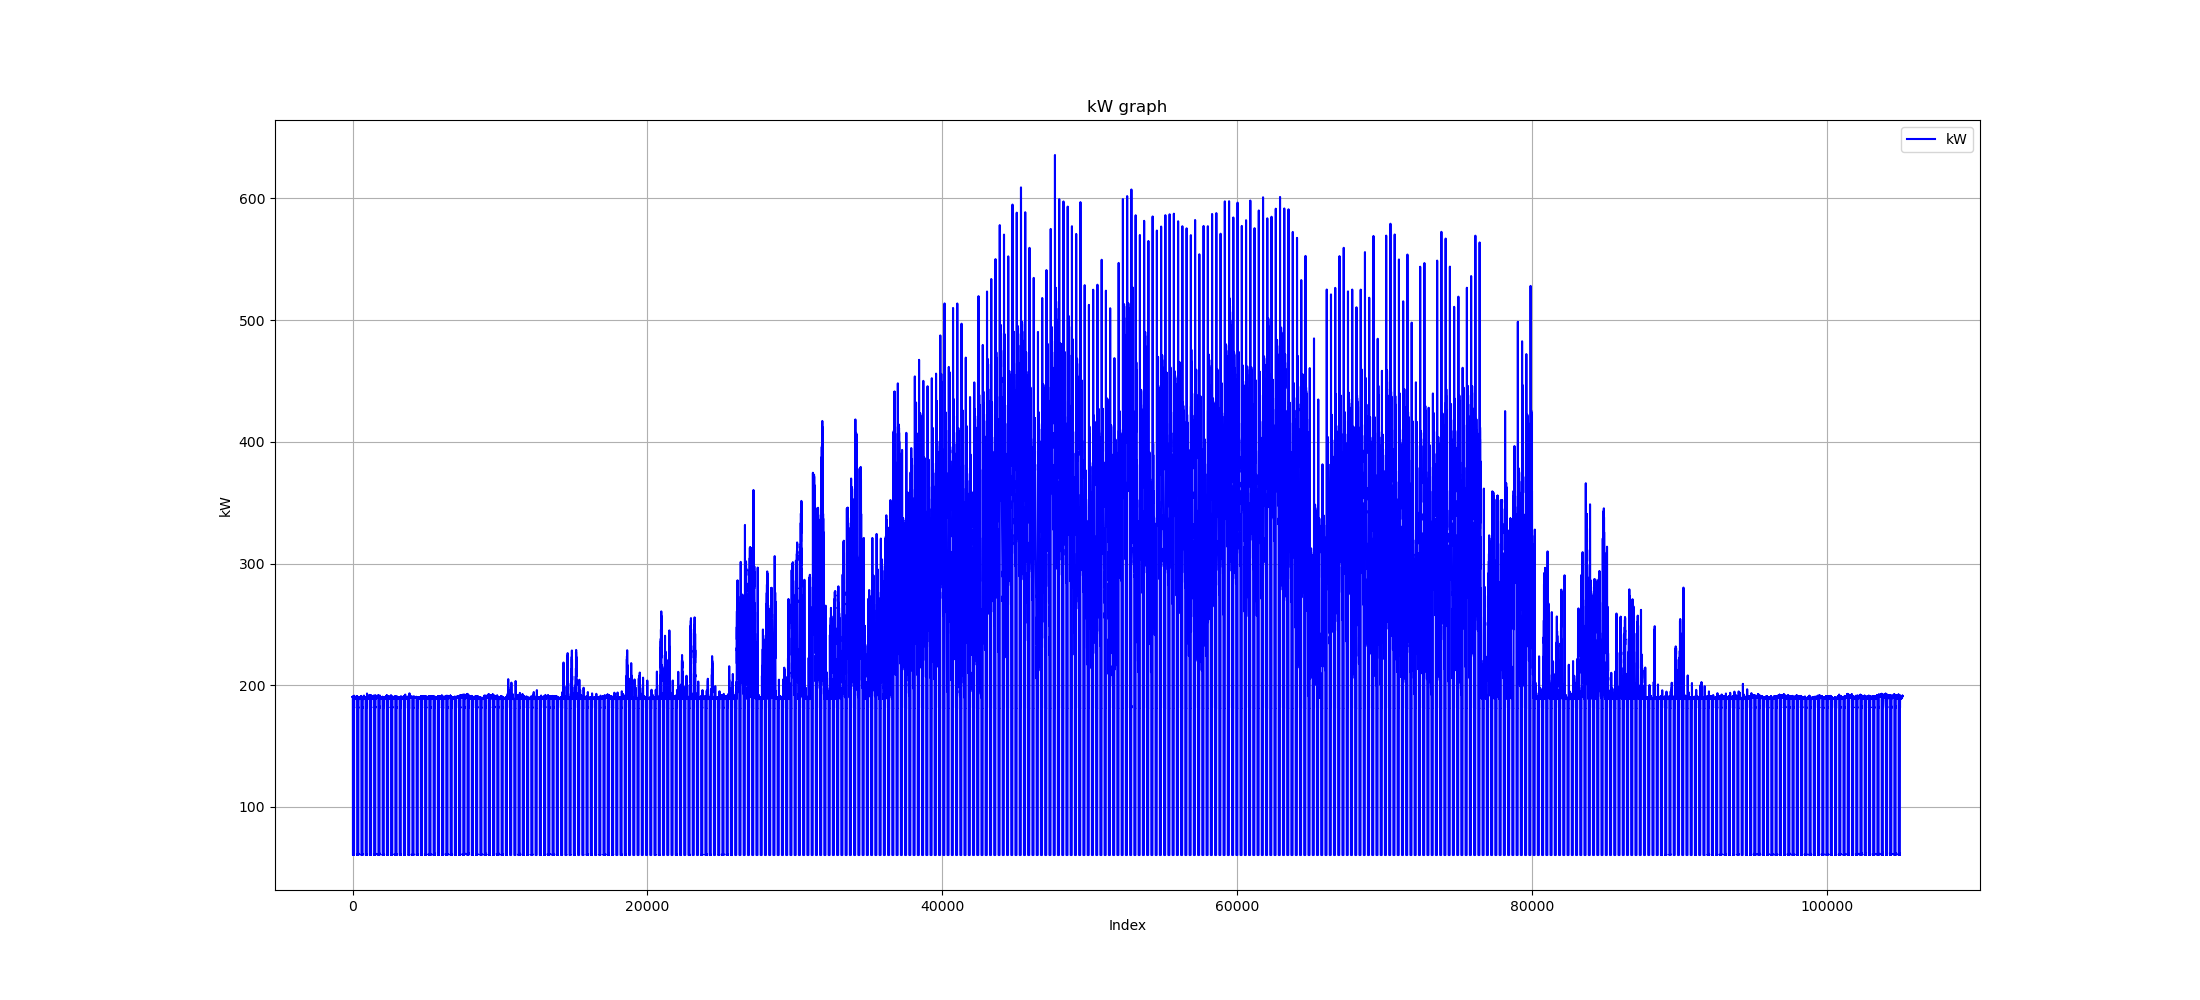

In [48]:
# start_index = 0
# end_index = 8640

plt.figure(figsize=(22,10))

# plt.plot(df_2["Demand kW"][start_index:end_index + 1], label="Demand W", color="blue")
plt.plot(df_2["Demand kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")
plt.grid(True)

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [49]:
# df['weekday'] = df['Date/Time'].dt.dayofweek

# from sklearn.preprocessing import OneHotEncoder

# # Initialize OneHotEncoder
# encoder = OneHotEncoder()

# # Fit and transform the weekday column
# weekday_encoded = encoder.fit_transform(df[['weekday']])

# # Convert the encoded result to a DataFrame
# weekday_encoded_df = pd.DataFrame(weekday_encoded.toarray(), columns=encoder.categories_[0])

# # change encoded values to int from float
# weekday_encoded_df = weekday_encoded_df.astype(int)

# # add a string to each column name for clarification
# weekday_encoded_df.columns = ['Weekday_' + str(col) for col in weekday_encoded_df.columns]

# display(weekday_encoded_df)

# # merge the columns
# for column in weekday_encoded_df.columns:
#     column_name_str = str(column)

#     df = df.join(weekday_encoded_df[column], rsuffix= 'Weekday: ' + column_name_str)

# # set index back to date time
# df.set_index('Date/Time', inplace=True)


# # Drop the weekday column
# df.drop(columns=['weekday'], inplace=True)

# display(df)   

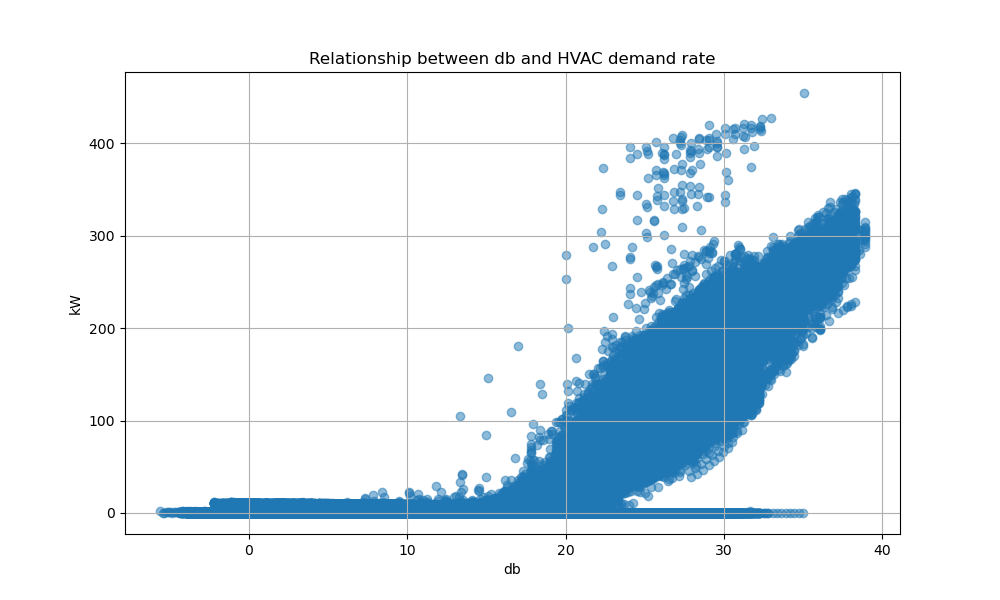

: 

In [50]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame containing the dataset
plt.figure(figsize=(10, 6))
plt.scatter(df['Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep)'], df['Whole Building:Facility Total HVAC Electricity Demand Rate [W](TimeStep)'] / 1000, alpha=0.5)
plt.title('Relationship between db and HVAC demand rate')
plt.xlabel('db')
plt.ylabel('kW')
plt.grid(True)
plt.show()